In [ ]:
# ==============================
# 📦 IMPORTS (FEATURE SELECTION)
# ==============================
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import (
    mutual_info_classif,
    VarianceThreshold,
    RFE,
    SequentialFeatureSelector
)

from sklearn.linear_model import LogisticRegression

# Display settings
pd.set_option('display.max_columns', None)

# ==============================
# 📂 LOAD CLEAN DATA
# ==============================
df = pd.read_csv("prepared.csv", parse_dates=["datetime"])

print("✅ Data loaded for Feature Selection")
display(df.head())

✅ Data loaded for Feature Selection


,year,month,day,hour,temp,dew_point,wet_bulb,rel_humidity,spec_humidity,pressure,wind_speed,wind_dir,precipitation,datetime,storm
0,2014,11,1,0,24.92,21.53,23.23,81.41,16.01,100.76,4.97,37.2,0.0,2014-11-01 00:00:00,0
1,2014,11,1,1,24.77,21.40,23.09,81.53,15.90,100.69,4.96,35.8,0.0,2014-11-01 01:00:00,0
2,2014,11,1,2,24.67,21.30,22.98,81.56,15.82,100.63,4.94,34.8,0.0,2014-11-01 02:00:00,0
3,2014,11,1,3,24.55,21.23,22.89,81.77,15.75,100.61,4.93,34.1,0.0,2014-11-01 03:00:00,0
4,2014,11,1,4,24.44,21.16,22.80,82.07,15.70,100.62,4.97,33.2,0.0,2014-11-01 04:00:00,0


#FEATURE SELECTION (FILTERS)

##CORRELATION HEATMAP

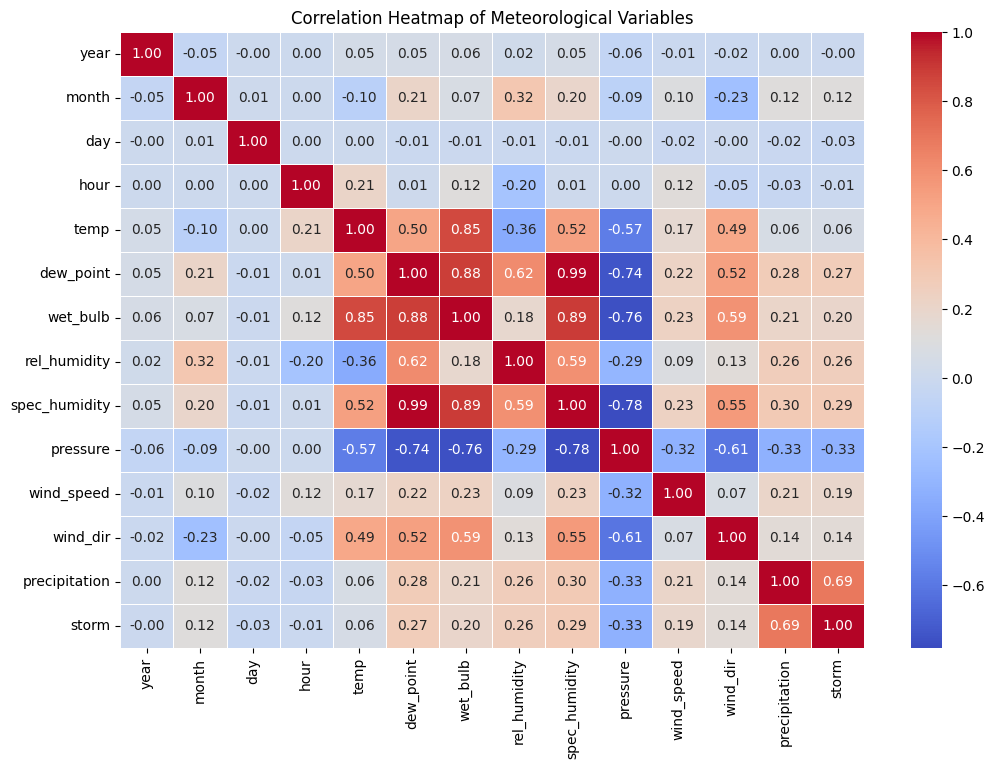

In [ ]:
# ==============================
# 📊 CORRELATION HEATMAP
# ==============================

plt.figure(figsize=(12, 8))

# Compute correlation matrix
corr = df.corr(numeric_only=True)

# Plot heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Meteorological Variables")
plt.show()

In [ ]:
# ==============================
# 🎯 CORRELATION WITH TARGET (STORM)
# ==============================

storm_corr = corr["storm"].sort_values(ascending=False)

print("Correlation with Storm:\n")
print(storm_corr)

Correlation with Storm:

storm            1.000000
precipitation    0.688628
spec_humidity    0.287152
dew_point        0.272000
rel_humidity     0.257154
wet_bulb         0.197931
wind_speed       0.191541
wind_dir         0.138246
month            0.121325
temp             0.058678
year            -0.002647
hour            -0.014141
day             -0.032347
pressure        -0.327107
Name: storm, dtype: float64


##MUTUAL INFORMATION

In [ ]:
# ==============================
# 🔍 MUTUAL INFORMATION
# ==============================

from sklearn.feature_selection import mutual_info_classif

# Use ALL features except target leakage
X_all = df.drop(columns=["storm", "precipitation", "datetime"])
y = df["storm"]

mi = mutual_info_classif(X_all, y)

mi_df = pd.DataFrame({
    "Feature": X_all.columns,
    "MI Score": mi
}).sort_values(by="MI Score", ascending=False)

print(mi_df)

          Feature  MI Score
8   spec_humidity  0.060893
5       dew_point  0.060036
1           month  0.059308
9        pressure  0.058425
7    rel_humidity  0.053308
6        wet_bulb  0.042156
4            temp  0.035046
10     wind_speed  0.021504
11       wind_dir  0.016688
2             day  0.003894
0            year  0.003860
3            hour  0.000928


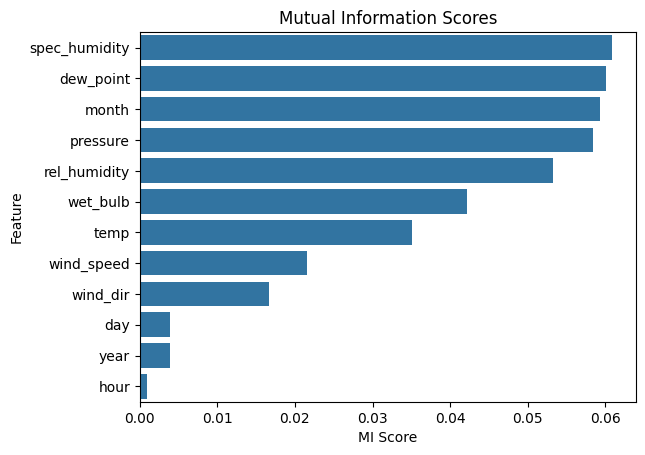

In [ ]:
plt.figure()
sns.barplot(x="MI Score", y="Feature", data=mi_df)
plt.title("Mutual Information Scores")
plt.show()

##VARIANCE THRESHOLD

In [ ]:
# ==============================
# 🔍 VARIANCE THRESHOLD
# ==============================

from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_all)

selected_features_var = X_all.columns[selector.get_support()]

print("Features after Variance Threshold:\n")
print(selected_features_var)

Features after Variance Threshold:

Index(['year', 'month', 'day', 'hour', 'temp', 'dew_point', 'wet_bulb',
       'rel_humidity', 'spec_humidity', 'pressure', 'wind_speed', 'wind_dir'],
      dtype='object')


#FEATURE SELECTION (WRAPPERS)

##RECURSIVE FEATURE ELIMINATION

In [ ]:
# ==============================
# 🔁 RFE (Recursive Feature Elimination)
# ==============================

from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

rfe = RFE(model, n_features_to_select=6)
rfe.fit(X_all, y)

rfe_df = pd.DataFrame({
    "Feature": X_all.columns,
    "Selected": rfe.support_,
    "Ranking": rfe.ranking_
}).sort_values(by="Ranking")

print(rfe_df)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

          Feature  Selected  Ranking
7    rel_humidity      True        1
6        wet_bulb      True        1
5       dew_point      True        1
4            temp      True        1
9        pressure      True        1
8   spec_humidity      True        1
10     wind_speed     False        2
1           month     False        3
0            year     False        4
3            hour     False        5
2             day     False        6
11       wind_dir     False        7


##FORWARD SELECTION

In [ ]:
# ==============================
# 🔁 FORWARD FEATURE SELECTION
# ==============================

from sklearn.feature_selection import SequentialFeatureSelector

model = LogisticRegression(max_iter=1000)

sfs = SequentialFeatureSelector(
    model,
    n_features_to_select=6,
    direction="forward"
)

sfs.fit(X_all, y)

selected_features_sfs = X_all.columns[sfs.get_support()]

print("Forward Selected Features:\n")
print(selected_features_sfs)

Forward Selected Features:

Index(['month', 'day', 'rel_humidity', 'pressure', 'wind_speed', 'wind_dir'], dtype='object')


##FINAL FEATURES

In [ ]:
final_features = [
    "spec_humidity",
    "dew_point",
    "rel_humidity",
    "pressure",
    "wet_bulb",
    "wind_speed"
]